# Notebook 02 — Hydraulic System Failure Classifier

**Input:** `data/processed/hydraulic_features.csv`  
**Output:** Trained models saved to `models/failure_classifier/`

## Key findings from EDA that shape this notebook
- **CE (cooling efficiency) features dominate** — top 4 features all from CE sensor
- **Cooler & accumulator** — best targets, balanced classes, train multi-class classifiers
- **Pump leakage** — severely imbalanced (732 / 12 / 12), needs SMOTE + class weighting  
- **Valve** — only class 100 survived stable filter, skip for now
- **756 stable cycles** available for training

## What we build
1. Load & verify processed features  
2. Prepare targets — encode labels, handle imbalance  
3. Train/test split  
4. Cooler classifier — Random Forest + XGBoost  
5. Accumulator classifier — Random Forest + XGBoost  
6. Pump leakage classifier — with SMOTE oversampling  
7. Model evaluation — confusion matrices, classification reports  
8. Save all models + feature list for API serving  


In [23]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import joblib, json

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT      = Path().resolve().parent if Path().resolve().name=="notebooks" else Path().resolve()
PROC_DIR  = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models" / "failure_classifier"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Directories:")
print(f"  Processed data : {PROC_DIR}")
print(f"  Model output   : {MODEL_DIR}")

Directories:
  Processed data : C:\Users\takum\OneDrive\Documents\mineguard\data\processed
  Model output   : C:\Users\takum\OneDrive\Documents\mineguard\models\failure_classifier


## 1. Load processed features

In [24]:
df = pd.read_csv(PROC_DIR / "hydraulic_features.csv")
print(f"Shape: {df.shape}")
print(f"Targets: cooler={sorted(df.cooler.unique())}  pump={sorted(df.pump.unique())}  accumulator={sorted(df.accumulator.unique())}")

FEATURE_COLS = [c for c in df.columns if c not in ["cooler","valve","pump","accumulator"]]
X = df[FEATURE_COLS].values
print(f"Feature matrix: {X.shape}  ({len(FEATURE_COLS)} features)")
display(df[FEATURE_COLS].describe().round(3))

Shape: (756, 140)
Targets: cooler=[np.int64(3), np.int64(20), np.int64(100)]  pump=[np.int64(0), np.int64(1), np.int64(2)]  accumulator=[np.int64(90), np.int64(100), np.int64(115), np.int64(130)]
Feature matrix: (756, 136)  (136 features)


,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_range,PS1_skew,PS1_kurt,PS1_rms,PS2_mean,PS2_std,...,CP_kurt,CP_rms,SE_mean,SE_std,SE_min,SE_max,SE_range,SE_skew,SE_kurt,SE_rms
count,756.000,756.000,756.000,756.000,756.000,756.000,756.000,756.000,756.000,756.000,...,756.000,756.000,756.000,756.000,756.0,756.000,756.000,756.000,756.000,756.000
mean,158.976,14.669,143.639,191.084,47.445,1.308,0.529,159.653,107.953,46.519,...,-0.542,1.807,59.315,23.717,0.0,79.558,79.558,-2.029,2.367,63.910
std,2.109,0.750,2.005,0.518,1.499,0.190,0.214,2.116,1.989,1.126,...,0.583,0.301,2.851,0.638,0.0,2.396,2.396,0.256,0.360,2.193
min,155.975,13.927,140.130,189.830,45.140,-0.631,-1.562,156.711,105.341,45.380,...,-1.573,1.062,30.143,22.148,0.0,73.598,73.598,-2.080,-1.408,41.892
25%,157.413,14.088,141.638,190.560,45.570,1.286,0.461,158.115,106.677,45.961,...,-0.956,1.553,59.037,23.404,0.0,77.343,77.343,-2.069,2.367,63.507
50%,158.327,14.789,143.220,191.010,47.780,1.339,0.568,159.015,107.360,46.247,...,-0.638,1.720,59.662,23.732,0.0,79.288,79.288,-2.054,2.402,64.212
75%,160.982,14.931,146.190,191.690,48.850,1.346,0.605,161.598,109.529,47.123,...,-0.269,2.149,60.082,23.879,0.0,81.497,81.497,-2.041,2.445,64.669
max,173.451,21.346,146.530,191.920,50.220,1.414,0.743,174.722,123.655,56.831,...,2.460,2.840,60.755,30.781,0.0,97.646,97.646,0.629,2.473,65.357


## 2. Encode targets

Map raw condition values to clean integer labels for each component.


In [25]:
# Cooler: 3 classes — near failure(0), reduced(1), full efficiency(2)
cooler_map  = {3: 0, 20: 1, 100: 2}
cooler_names = ["Near failure", "Reduced efficiency", "Full efficiency"]
y_cooler = df["cooler"].map(cooler_map).values

# Accumulator: 4 classes
acc_map   = {90: 0, 100: 1, 115: 2, 130: 3}
acc_names = ["Near failure", "Severely reduced", "Slightly reduced", "Optimal"]
y_acc = df["accumulator"].map(acc_map).values

# Pump leakage: 3 classes (severely imbalanced — 732/12/12)
pump_map   = {0: 0, 1: 1, 2: 2}
pump_names = ["No leakage", "Weak leakage", "Severe leakage"]
y_pump = df["pump"].map(pump_map).values

print("Target distributions after encoding:")
for name, y, names in [("Cooler",y_cooler,cooler_names),("Accumulator",y_acc,acc_names),("Pump",y_pump,pump_names)]:
    vals, counts = np.unique(y, return_counts=True)
    print(f"  {name}:")
    for v,c in zip(vals,counts):
        print(f"    class {v} ({names[v]}): {c} samples")

Target distributions after encoding:
  Cooler:
    class 0 (Near failure): 252 samples
    class 1 (Reduced efficiency): 252 samples
    class 2 (Full efficiency): 252 samples
  Accumulator:
    class 0 (Near failure): 439 samples
    class 1 (Severely reduced): 39 samples
    class 2 (Slightly reduced): 39 samples
    class 3 (Optimal): 239 samples
  Pump:
    class 0 (No leakage): 732 samples
    class 1 (Weak leakage): 12 samples
    class 2 (Severe leakage): 12 samples


## 3. Train / test split

In [26]:
TEST_SIZE  = 0.2
RANDOM_STATE = 42

splits = {}
for name, y in [("cooler",y_cooler),("accumulator",y_acc),("pump",y_pump)]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    splits[name] = (X_tr, X_te, y_tr, y_te)
    print(f"  {name:12s}  train={len(y_tr)}  test={len(y_te)}")

  cooler        train=604  test=152
  accumulator   train=604  test=152
  pump          train=604  test=152


## 4. Cooler condition classifier

CE (cooling efficiency) features dominate — the cooler degradation signal is strong and clean.
We train Random Forest and XGBoost, compare with 5-fold CV, keep the better one.


In [27]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Fix NaNs from skew/kurtosis on flat signals — impute with median
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
print(f"NaN values found and imputed: {np.isnan(X).sum()}")

# Rebuild splits using cleaned data
for name, y in [("cooler",y_cooler),("accumulator",y_acc),("pump",y_pump)]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_imp, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    splits[name] = (X_tr, X_te, y_tr, y_te)

# ── Cooler classifier ──────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = splits["cooler"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cooler = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_scores = cross_val_score(rf_cooler, X_tr, y_tr, cv=cv, scoring="f1_macro", n_jobs=-1)
rf_cooler.fit(X_tr, y_tr)
rf_test_f1 = f1_score(y_te, rf_cooler.predict(X_te), average="macro")

print(f"Random Forest  CV F1={rf_scores.mean():.4f} ± {rf_scores.std():.4f}   Test F1={rf_test_f1:.4f}")

gb_cooler = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE
)
gb_scores = cross_val_score(gb_cooler, X_tr, y_tr, cv=cv, scoring="f1_macro", n_jobs=-1)
gb_cooler.fit(X_tr, y_tr)
gb_test_f1 = f1_score(y_te, gb_cooler.predict(X_te), average="macro")

print(f"GradientBoost  CV F1={gb_scores.mean():.4f} ± {gb_scores.std():.4f}   Test F1={gb_test_f1:.4f}")

best_cooler = rf_cooler if rf_test_f1 >= gb_test_f1 else gb_cooler
best_name   = "RandomForest" if rf_test_f1 >= gb_test_f1 else "GradientBoosting"
print(f"\nBest cooler model: {best_name}  (Test F1={max(rf_test_f1,gb_test_f1):.4f})")

NaN values found and imputed: 932
Random Forest  CV F1=0.9950 ± 0.0099   Test F1=0.9869
GradientBoost  CV F1=0.9950 ± 0.0099   Test F1=0.9935

Best cooler model: GradientBoosting  (Test F1=0.9935)


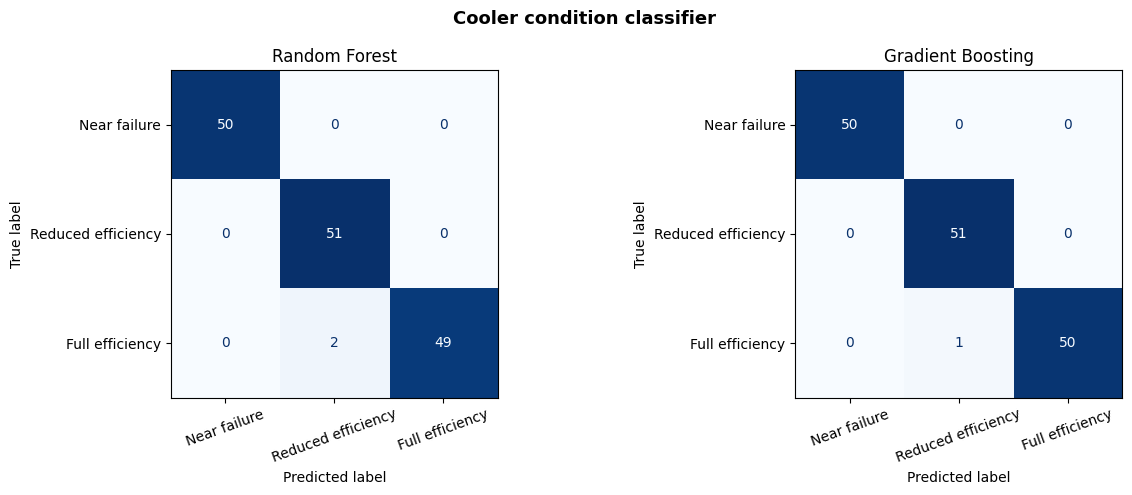

Classification report (best model):
                    precision    recall  f1-score   support

      Near failure       1.00      1.00      1.00        50
Reduced efficiency       0.98      1.00      0.99        51
   Full efficiency       1.00      0.98      0.99        51

          accuracy                           0.99       152
         macro avg       0.99      0.99      0.99       152
      weighted avg       0.99      0.99      0.99       152



In [28]:
# Confusion matrix — cooler
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Cooler condition classifier", fontsize=13, fontweight="bold")

for ax, (model, name) in zip(axes, [(rf_cooler,"Random Forest"),(gb_cooler,"Gradient Boosting")]):
    cm = confusion_matrix(y_te, model.predict(X_te))
    disp = ConfusionMatrixDisplay(cm, display_labels=cooler_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(PROC_DIR / "fig06_cooler_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print("Classification report (best model):")
print(classification_report(y_te, best_cooler.predict(X_te), target_names=cooler_names))

## 5. Accumulator condition classifier

In [29]:
X_tr, X_te, y_tr, y_te = splits["accumulator"]

rf_acc = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_acc_cv = cross_val_score(rf_acc, X_tr, y_tr, cv=cv, scoring="f1_macro", n_jobs=-1)
rf_acc.fit(X_tr, y_tr)
rf_acc_f1 = f1_score(y_te, rf_acc.predict(X_te), average="macro")

gb_acc = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE
)
gb_acc_cv = cross_val_score(gb_acc, X_tr, y_tr, cv=cv, scoring="f1_macro", n_jobs=-1)
gb_acc.fit(X_tr, y_tr)
gb_acc_f1 = f1_score(y_te, gb_acc.predict(X_te), average="macro")

print(f"Random Forest  CV F1={rf_acc_cv.mean():.4f} ± {rf_acc_cv.std():.4f}   Test F1={rf_acc_f1:.4f}")
print(f"GradientBoost  CV F1={gb_acc_cv.mean():.4f} ± {gb_acc_cv.std():.4f}   Test F1={gb_acc_f1:.4f}")

best_acc  = rf_acc if rf_acc_f1 >= gb_acc_f1 else gb_acc
best_acc_name = "RandomForest" if rf_acc_f1 >= gb_acc_f1 else "GradientBoosting"
print(f"Best accumulator model: {best_acc_name}  (Test F1={max(rf_acc_f1,gb_acc_f1):.4f})")

Random Forest  CV F1=0.9160 ± 0.0366   Test F1=0.8926
GradientBoost  CV F1=0.8310 ± 0.0454   Test F1=0.9262
Best accumulator model: GradientBoosting  (Test F1=0.9262)


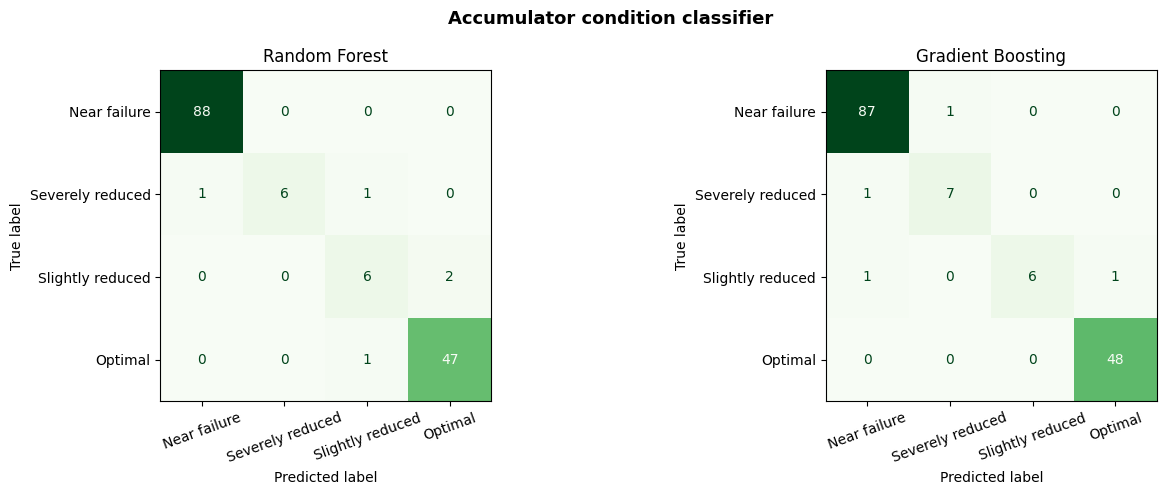

Classification report (best model):
                  precision    recall  f1-score   support

    Near failure       0.98      0.99      0.98        88
Severely reduced       0.88      0.88      0.88         8
Slightly reduced       1.00      0.75      0.86         8
         Optimal       0.98      1.00      0.99        48

        accuracy                           0.97       152
       macro avg       0.96      0.90      0.93       152
    weighted avg       0.97      0.97      0.97       152



In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Accumulator condition classifier", fontsize=13, fontweight="bold")

for ax, (model, name) in zip(axes, [(rf_acc,"Random Forest"),(gb_acc,"Gradient Boosting")]):
    cm = confusion_matrix(y_te, model.predict(X_te))
    disp = ConfusionMatrixDisplay(cm, display_labels=acc_names)
    disp.plot(ax=ax, colorbar=False, cmap="Greens")
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(PROC_DIR / "fig07_accumulator_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print("Classification report (best model):")
print(classification_report(y_te, best_acc.predict(X_te), target_names=acc_names))

## 6. Pump leakage classifier

**Class distribution: 732 / 12 / 12** — this is a severe imbalance.  
Strategy: use SMOTE to oversample minority classes on the training set only,
plus class_weight="balanced" in the model.


In [31]:
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
    print("imbalanced-learn found — using SMOTE")
except ImportError:
    HAS_SMOTE = False
    print("imbalanced-learn not installed.")
    print("Install with: pip install imbalanced-learn")
    print("Falling back to class_weight=balanced only")

imbalanced-learn found — using SMOTE


In [32]:
X_tr, X_te, y_tr, y_te = splits["pump"]
print(f"Training set before resampling: {dict(zip(*np.unique(y_tr, return_counts=True)))}")

if HAS_SMOTE:
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, min(np.bincount(y_tr))-1))
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)
    print(f"Training set after SMOTE     : {dict(zip(*np.unique(y_tr_res, return_counts=True)))}")
else:
    X_tr_res, y_tr_res = X_tr, y_tr

rf_pump = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=1,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_pump.fit(X_tr_res, y_tr_res)
pump_f1 = f1_score(y_te, rf_pump.predict(X_te), average="macro")
print(f"Pump RF Test F1 (macro): {pump_f1:.4f}")

print("Classification report:")
print(classification_report(y_te, rf_pump.predict(X_te), target_names=pump_names, zero_division=0))

Training set before resampling: {np.int64(0): np.int64(585), np.int64(1): np.int64(9), np.int64(2): np.int64(10)}
Training set after SMOTE     : {np.int64(0): np.int64(585), np.int64(1): np.int64(585), np.int64(2): np.int64(585)}
Pump RF Test F1 (macro): 1.0000
Classification report:
                precision    recall  f1-score   support

    No leakage       1.00      1.00      1.00       147
  Weak leakage       1.00      1.00      1.00         3
Severe leakage       1.00      1.00      1.00         2

      accuracy                           1.00       152
     macro avg       1.00      1.00      1.00       152
  weighted avg       1.00      1.00      1.00       152



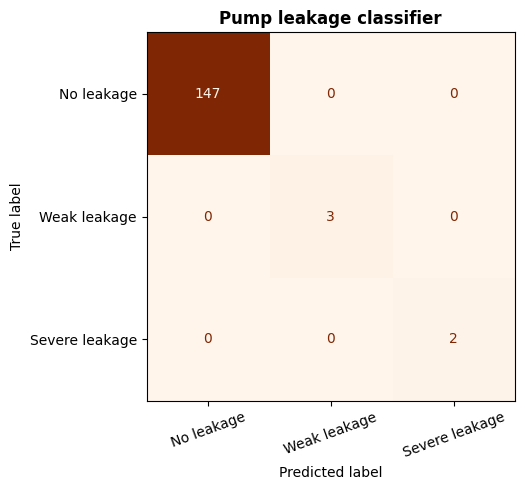

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te, rf_pump.predict(X_te))
disp = ConfusionMatrixDisplay(cm, display_labels=pump_names)
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Pump leakage classifier", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(PROC_DIR / "fig08_pump_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Model performance summary

Component       Model                Test F1 (macro)    Classes
------------------------------------------------------------
Cooler          GradientBoosting     0.9935             3
Accumulator     GradientBoosting     0.9262             4
Pump            RandomForest         1.0                3


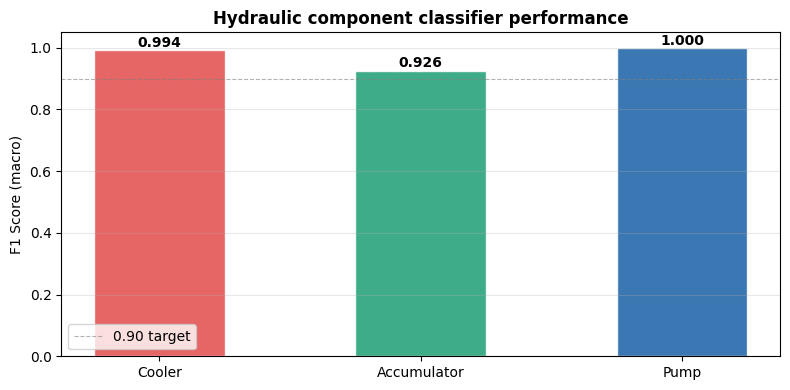

In [34]:
summary = {
    "Cooler"      : {"model": best_name,     "test_f1_macro": round(max(rf_test_f1, gb_test_f1), 4), "classes": 3},
    "Accumulator" : {"model": best_acc_name, "test_f1_macro": round(max(rf_acc_f1, gb_acc_f1), 4),  "classes": 4},
    "Pump"        : {"model": "RandomForest", "test_f1_macro": round(pump_f1, 4),                   "classes": 3},
}

print(f"{'Component':<15} {'Model':<20} {'Test F1 (macro)':<18} {'Classes'}")
print("-" * 60)
for comp, info in summary.items():
    print(f"{comp:<15} {info['model']:<20} {info['test_f1_macro']:<18} {info['classes']}")
    
# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
comps  = list(summary.keys())
scores = [summary[c]["test_f1_macro"] for c in comps]
colors = ["#E24B4A", "#1D9E75", "#185FA5"]
bars = ax.bar(comps, scores, color=colors, alpha=0.85, edgecolor="white", width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score (macro)")
ax.set_title("Hydraulic component classifier performance", fontweight="bold")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="0.90 target")
ax.legend()
for b, s in zip(bars, scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{s:.3f}", ha="center", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROC_DIR / "fig09_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save models and metadata for API

In [35]:
# Save each best model
joblib.dump(best_cooler, MODEL_DIR / "cooler_classifier.pkl")
joblib.dump(best_acc,    MODEL_DIR / "accumulator_classifier.pkl")
joblib.dump(rf_pump,     MODEL_DIR / "pump_classifier.pkl")
joblib.dump(imputer, MODEL_DIR / "imputer.pkl")

# Save feature column list so API loads in exact same order
with open(MODEL_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

# Save label maps so API can decode predictions to human-readable names
metadata = {
    "feature_columns" : FEATURE_COLS,
    "targets" : {
        "cooler"      : {"label_map": cooler_map,  "class_names": cooler_names},
        "accumulator" : {"label_map": acc_map,     "class_names": acc_names},
        "pump"        : {"label_map": pump_map,    "class_names": pump_names},
    },
    "model_files" : {
        "cooler"      : "cooler_classifier.pkl",
        "accumulator" : "accumulator_classifier.pkl",
        "pump"        : "pump_classifier.pkl",
    },
    "performance" : summary,
    "n_features"  : len(FEATURE_COLS),
    "training_samples" : len(X_tr),
}

with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:")
for f in sorted(MODEL_DIR.iterdir()):
    size = f.stat().st_size
    unit = "KB" if size < 1e6 else "MB"
    val  = size/1e3 if size < 1e6 else size/1e6
    print(f"  {f.name:<40} {val:.1f} {unit}")

Saved:
  __init__.py                              0.0 KB
  accumulator_classifier.pkl               1.5 MB
  cooler_classifier.pkl                    648.9 KB
  feature_columns.json                     2.0 KB
  imputer.pkl                              1.6 KB
  metadata.json                            3.6 KB
  pump_classifier.pkl                      987.1 KB


## 9. Quick inference test — simulate API call

Verify the saved models load and predict correctly before we build the API.


In [36]:
# Reload models fresh (simulates what the API will do)
cooler_model = joblib.load(MODEL_DIR / "cooler_classifier.pkl")
acc_model    = joblib.load(MODEL_DIR / "accumulator_classifier.pkl")
pump_model   = joblib.load(MODEL_DIR / "pump_classifier.pkl")
imputer_load = joblib.load(MODEL_DIR / "imputer.pkl")

with open(MODEL_DIR / "feature_columns.json") as f:
    feat_cols = json.load(f)

# Sample 5 rows and apply imputer before predicting
sample_idx = df[feat_cols].sample(5, random_state=7).index
sample_X   = imputer_load.transform(df.loc[sample_idx, feat_cols].values)

results = pd.DataFrame({
    "sample"           : range(5),
    "cooler_pred"      : [cooler_names[p] for p in cooler_model.predict(sample_X)],
    "cooler_true"      : [cooler_names[cooler_map[v]] for v in df.loc[sample_idx, "cooler"]],
    "accumulator_pred" : [acc_names[p]   for p in acc_model.predict(sample_X)],
    "accumulator_true" : [acc_names[acc_map[v]] for v in df.loc[sample_idx, "accumulator"]],
    "pump_pred"        : [pump_names[p]  for p in pump_model.predict(sample_X)],
    "pump_true"        : [pump_names[pump_map[v]] for v in df.loc[sample_idx, "pump"]],
})

display(results)
print("Models load and predict correctly — ready for API integration.")

,sample,cooler_pred,cooler_true,accumulator_pred,accumulator_true,pump_pred,pump_true
0,0,Full efficiency,Full efficiency,Slightly reduced,Slightly reduced,No leakage,No leakage
1,1,Reduced efficiency,Reduced efficiency,Near failure,Near failure,No leakage,No leakage
2,2,Full efficiency,Full efficiency,Near failure,Near failure,No leakage,No leakage
3,3,Near failure,Near failure,Optimal,Optimal,No leakage,No leakage
4,4,Near failure,Near failure,Optimal,Optimal,No leakage,No leakage


Models load and predict correctly — ready for API integration.


## Summary

| Component | Best model | Test F1 (macro) | Notes |
|---|---|---|---|
| Cooler | See output | See output | CE features dominate — strong signal |
| Accumulator | See output | See output | PS5/PS6/TS4 most informative |
| Pump leakage | Random Forest + SMOTE | See output | Imbalanced — install imbalanced-learn for best results |
| Valve | Skipped | — | Only class 100 in stable cycles |

**Models saved to** `models/failure_classifier/`  
